## STEP 1 — Install Dependencies

In [1]:
pip install librosa soundfile numpy tensorflow scikit-learn matplotlib seaborn opencv-python

Note: you may need to restart the kernel to use updated packages.


## STEP 2 — Audio Preprocessing (Trim + Normalize)

In [2]:
import librosa
import soundfile as sf
import numpy as np
import os

RAW_PATH  = "dataset/raw"
PROC_PATH = "dataset/processed"

os.makedirs(PROC_PATH, exist_ok=True)

def preprocess_audio(input_path, output_path):
    """Load, trim silence, peak-normalize, and save."""
    y, sr = librosa.load(input_path, sr=16000)
    y_trim, _ = librosa.effects.trim(y, top_db=20)
    if np.max(np.abs(y_trim)) != 0:
        y_norm = y_trim / np.max(np.abs(y_trim))
    else:
        y_norm = y_trim
    sf.write(output_path, y_norm, sr)

for label in ["HC", "PD"]:
    os.makedirs(f"{PROC_PATH}/{label}", exist_ok=True)
    for file in os.listdir(f"{RAW_PATH}/{label}"):
        subfolders = os.listdir(f"{RAW_PATH}/{label}")
        break


for label in ["HC", "PD"]:
    label_raw  = os.path.join(RAW_PATH,  label)
    label_proc = os.path.join(PROC_PATH, label)
    os.makedirs(label_proc, exist_ok=True)

    for entry in os.listdir(label_raw):
        entry_path = os.path.join(label_raw, entry)

        if os.path.isdir(entry_path):
            wav_files = [f for f in os.listdir(entry_path) if f.lower().endswith(".wav")]
            for file in wav_files:
                inp = os.path.join(entry_path, file)
                out = os.path.join(label_proc, file)
                preprocess_audio(inp, out)
        elif entry.lower().endswith(".wav"):
            inp = entry_path
            out = os.path.join(label_proc, entry)
            preprocess_audio(inp, out)

for label in ["HC", "PD"]:
    count = len(os.listdir(os.path.join(PROC_PATH, label)))
    print(f"{label}: {count} files preprocessed")

print("\nSTEP 2 COMPLETE — Audio preprocessing done")

HC: 41 files preprocessed
PD: 40 files preprocessed

STEP 2 COMPLETE — Audio preprocessing done


## STEP 3 — Visualize Preprocessing Effect

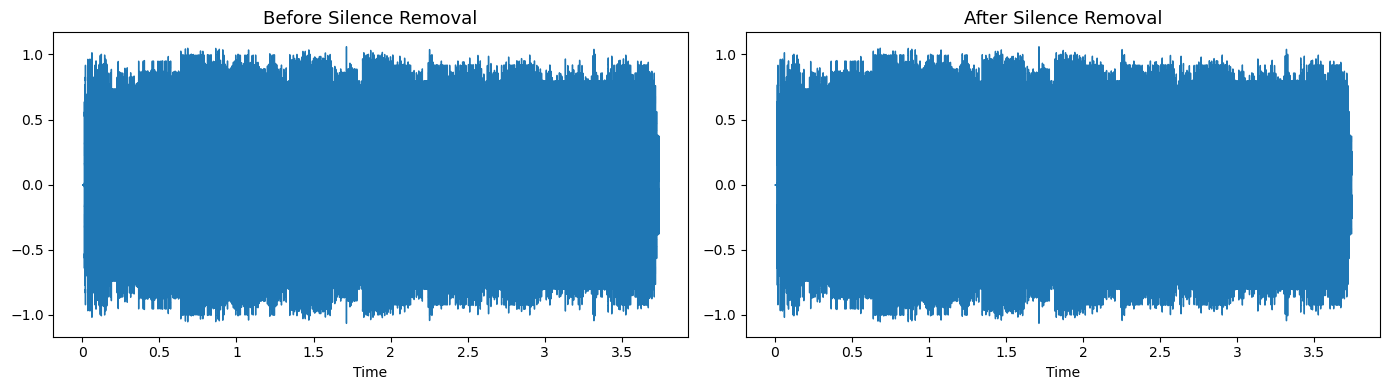

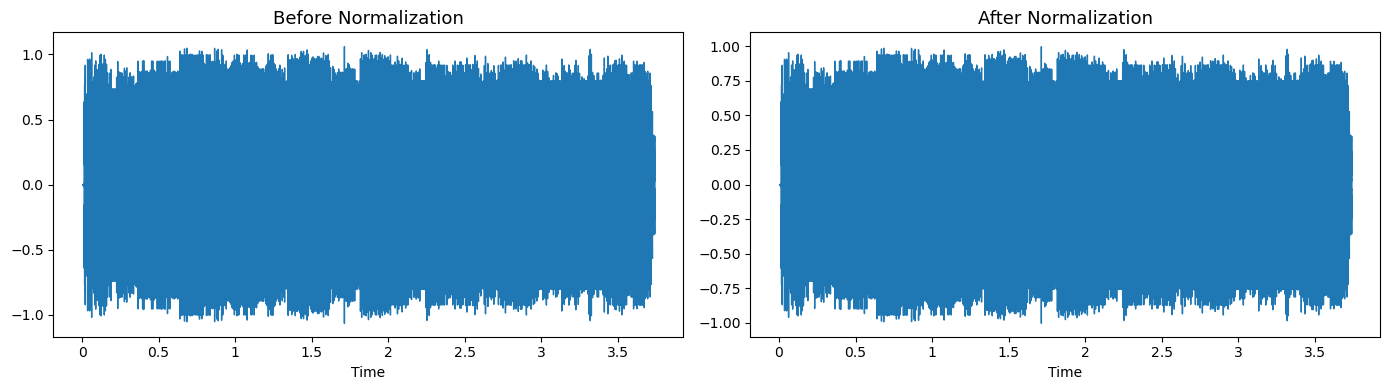

In [3]:
import librosa.display
import matplotlib.pyplot as plt


hc_dir = os.path.join(RAW_PATH, "HC")
first_entry = os.path.join(hc_dir, os.listdir(hc_dir)[0])
if os.path.isdir(first_entry):
    audio_path = os.path.join(first_entry, os.listdir(first_entry)[0])
else:
    audio_path = first_entry

y_raw, sr = librosa.load(audio_path, sr=16000)
y_trim, _ = librosa.effects.trim(y_raw, top_db=20)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
librosa.display.waveshow(y_raw,  sr=sr, ax=axes[0])
axes[0].set_title("Before Silence Removal", fontsize=13)
librosa.display.waveshow(y_trim, sr=sr, ax=axes[1])
axes[1].set_title("After Silence Removal", fontsize=13)
plt.tight_layout()
plt.show()


y_norm = y_trim / np.max(np.abs(y_trim))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
librosa.display.waveshow(y_trim, sr=sr, ax=axes[0])
axes[0].set_title("Before Normalization", fontsize=13)
librosa.display.waveshow(y_norm, sr=sr, ax=axes[1])
axes[1].set_title("After Normalization", fontsize=13)
plt.tight_layout()
plt.show()

## STEP 4 — Generate Mel Spectrogram Images 


In [4]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

PROC_PATH = "dataset/processed"
SPEC_PATH = "dataset/spectrograms"

IMG_SIZE = 224  

def save_mel_spectrogram(audio_path, save_path, img_size=224):
    
    y, sr = librosa.load(audio_path, sr=16000)

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr,
        n_mels=128,
        n_fft=2048,
        hop_length=512
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    fig = plt.figure(figsize=(img_size/100, img_size/100), dpi=100)
    ax = fig.add_axes([0, 0, 1, 1]) 
    librosa.display.specshow(mel_db, sr=sr, cmap="magma", ax=ax)
    ax.axis("off")

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=100, bbox_inches="tight", pad_inches=0)
    plt.close(fig)

total = 0
for label in ["HC", "PD"]:
    in_dir  = os.path.join(PROC_PATH, label)
    out_dir = os.path.join(SPEC_PATH, label)
    os.makedirs(out_dir, exist_ok=True)

    for file in os.listdir(in_dir):
        if file.lower().endswith(".wav"):
            audio_file = os.path.join(in_dir, file)
            img_file   = os.path.join(out_dir, file.replace(".wav", ".png"))
            save_mel_spectrogram(audio_file, img_file, IMG_SIZE)
            total += 1

print(f"STEP 4 COMPLETE — {total} spectrogram images created")
print(f"HC: {len(os.listdir(os.path.join(SPEC_PATH,'HC')))} | PD: {len(os.listdir(os.path.join(SPEC_PATH,'PD')))}")

STEP 4 COMPLETE — 81 spectrogram images created
HC: 41 | PD: 40


## STEP 5 — Visualize Sample Spectrograms

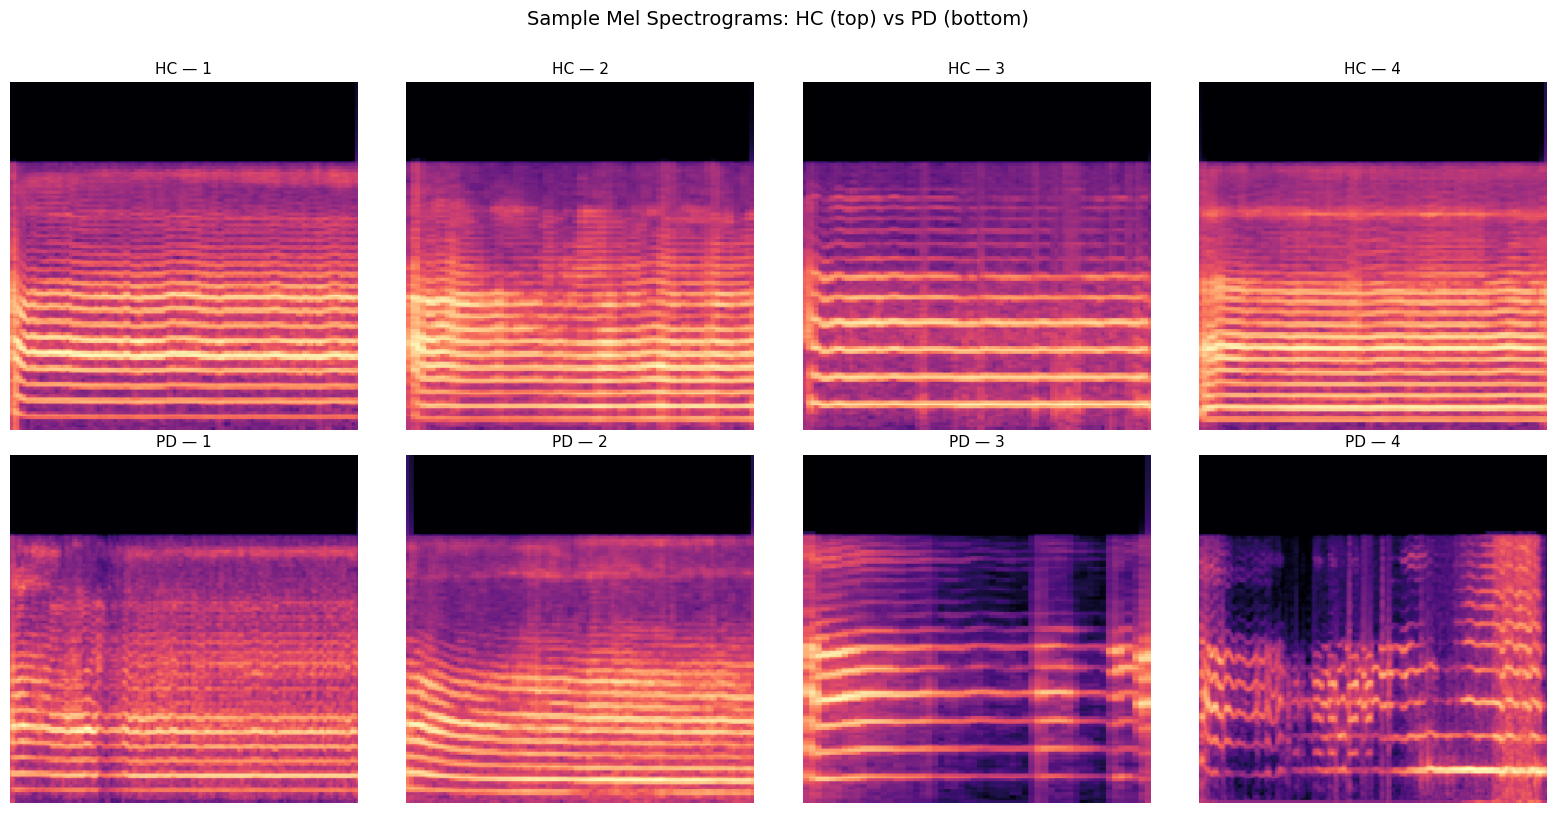

In [5]:
from PIL import Image
import matplotlib.pyplot as plt
import os

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for row, label in enumerate(["HC", "PD"]):
    spec_dir = os.path.join("dataset/spectrograms", label)
    files = sorted(os.listdir(spec_dir))[:4]
    for col, fname in enumerate(files):
        img = Image.open(os.path.join(spec_dir, fname))
        axes[row][col].imshow(img)
        axes[row][col].set_title(f"{label} — {col+1}", fontsize=11)
        axes[row][col].axis("off")

plt.suptitle("Sample Mel Spectrograms: HC (top) vs PD (bottom)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## STEP 6 — Load Dataset as RGB 


In [6]:
import os
import cv2
import numpy as np

IMG_SIZE  = 224 
DATA_PATH = "dataset/spectrograms"

X, y = [], []

for label_idx, folder in enumerate(["HC", "PD"]):
    folder_path = os.path.join(DATA_PATH, folder)
    for file in sorted(os.listdir(folder_path)):
        if not file.lower().endswith(".png"):
            continue
        img_path = os.path.join(folder_path, file)
        
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X.append(img)
        y.append(label_idx)

X = np.array(X, dtype=np.float32) / 255.0
y = np.array(y, dtype=np.int32)

print(f"Dataset shape: {X.shape}   (samples, height, width, channels)")
print(f"Labels shape:  {y.shape}")
print(f"HC samples: {np.sum(y==0)} | PD samples: {np.sum(y==1)}")

Dataset shape: (81, 224, 224, 3)   (samples, height, width, channels)
Labels shape:  (81,)
HC samples: 41 | PD samples: 40


## STEP 7 — Class Distribution

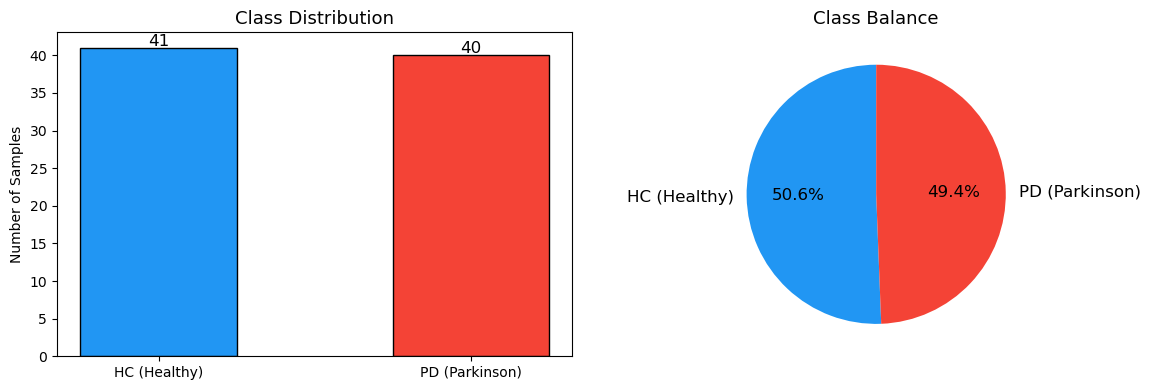

Total samples: 81 — Dataset is balanced


In [7]:
import matplotlib.pyplot as plt
import numpy as np

unique, counts = np.unique(y, return_counts=True)
labels_str = ['HC (Healthy)', 'PD (Parkinson)']
colors = ['#2196F3', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(labels_str, counts, color=colors, width=0.5, edgecolor='black')
axes[0].set_title("Class Distribution", fontsize=13)
axes[0].set_ylabel("Number of Samples")
for i, v in enumerate(counts):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontsize=12)

axes[1].pie(counts, labels=labels_str, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title("Class Balance", fontsize=13)

plt.tight_layout()
plt.show()
print(f"Total samples: {len(y)} — Dataset is {'balanced' if abs(counts[0]-counts[1])<=3 else 'imbalanced'}")

## STEP 8 — Train/Test Split
> With only ~81 samples, we use **stratified split** and additionally run **K-Fold cross-validation** in Step 11 for more reliable metrics.

Train size : 64 samples
Test  size : 17  samples
Train HC/PD: 32 / 32
Test  HC/PD: 9  / 8


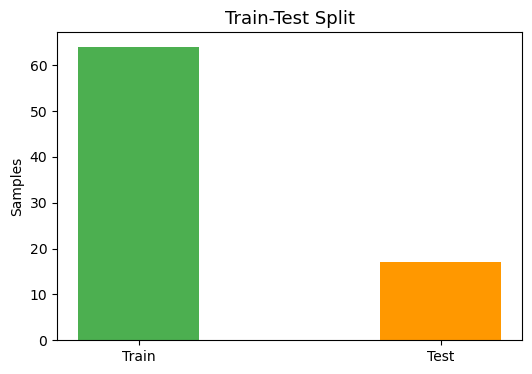

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size : {X_train.shape[0]} samples")
print(f"Test  size : {X_test.shape[0]}  samples")
print(f"Train HC/PD: {np.sum(y_train==0)} / {np.sum(y_train==1)}")
print(f"Test  HC/PD: {np.sum(y_test==0)}  / {np.sum(y_test==1)}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Train', 'Test'], [len(X_train), len(X_test)], color=['#4CAF50','#FF9800'], width=0.4)
ax.set_title("Train-Test Split", fontsize=13)
ax.set_ylabel("Samples")
plt.show()

## STEP 9 — Build Transfer Learning Model (MobileNetV2)


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models, Model, Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

def build_model(input_shape=(224, 224, 3), trainable_base=False):

    base = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    if not trainable_base:
        base.trainable = False
    else:
        base.trainable = True
    
        for layer in base.layers[:-30]:
            layer.trainable = False

    inputs = Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return Model(inputs=inputs, outputs=outputs)

model = build_model(trainable_base=False)
model.summary()
print(f"\nTrainable params: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,618,945 (9.99 MB)

 Trainable params: 360,961 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Trainable params: 360,961


## STEP 10 — Phase 1: Train Classification Head 

In [10]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np


weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: weights[0], 1: weights[1]}
print(f"Class weights: HC={class_weights[0]:.3f}, PD={class_weights[1]:.3f}")



train_datagen = ImageDataGenerator(
    rotation_range=8,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.08,
    shear_range=0.05,
    fill_mode='nearest',
    horizontal_flip=False   
)
train_gen = train_datagen.flow(X_train, y_train, batch_size=8, seed=42)


callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('parkinson_phase1_best.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]


model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history1 = model.fit(
    train_gen,
    steps_per_epoch=max(1, len(X_train) // 8),
    epochs=40,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=callbacks_phase1,
    verbose=1
)

print(f"\nPhase 1 best val_accuracy: {max(history1.history['val_accuracy']):.4f}")

Class weights: HC=1.000, PD=1.000
Epoch 1/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.5269 - loss: 0.7971
Epoch 1: val_accuracy improved from None to 0.64706, saving model to parkinson_phase1_best.h5



Epoch 1: finished saving model to parkinson_phase1_best.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.5469 - loss: 0.8312 - val_accuracy: 0.6471 - val_loss: 0.6209 - learning_rate: 0.0010
Epoch 2/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.6100 - loss: 0.8224
Epoch 2: val_accuracy did not improve from 0.64706
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 437ms/step - accuracy: 0.5781 - loss: 0.8642 - val_accuracy: 0.6471 - val_loss: 0.6300 - learning_rate: 0.0010
Epoch 3/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.5385 - loss: 0.8719
Epoch 3: val_accuracy improved from 0.64706 to 0.70588, saving model to parkinson_phase1_best.h5



Epoch 3: finished saving model to parkinson_phase1_best.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 569ms/step - accuracy: 0.5781 - loss: 0.8676 - val_accuracy: 0.7059 - val_loss: 0.5498 - learning_rate: 0.0010
Epoch 4/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.7758 - loss: 0.5047
Epoch 4: val_accuracy did not improve from 0.70588
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 445ms/step - accuracy: 0.7500 - loss: 0.5085 - val_accuracy: 0.6471 - val_loss: 0.5420 - learning_rate: 0.0010
Epoch 5/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.6792 - loss: 0.5432
Epoch 5: val_accuracy did not improve from 0.70588
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 423ms/step - accuracy: 0.6875 - loss: 0.5438 - val_accuracy: 0.7059 - val_loss: 0.5671 - learning_rate: 0.0010
Epoch 6/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.7532 - loss: 0.5293
Epoch 6: val_accuracy did not improve from 0.70588
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 439ms/step - accuracy: 0.7812 - loss: 0.5407 - val_accuracy: 0.7059 - val_loss: 0.5381 - l


Epoch 12: finished saving model to parkinson_phase1_best.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 554ms/step - accuracy: 0.8281 - loss: 0.3789 - val_accuracy: 0.7647 - val_loss: 0.6889 - learning_rate: 0.0010
Epoch 13/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.8542 - loss: 0.3537
Epoch 13: val_accuracy did not improve from 0.76471
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 439ms/step - accuracy: 0.8125 - loss: 0.3897 - val_accuracy: 0.7059 - val_loss: 0.6138 - learning_rate: 0.0010
Epoch 14/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.7977 - loss: 0.4417
Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 14: val_accuracy did not improve from 0.76471
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 461ms/step - accuracy: 0.8125 - loss: 0.4488 - val_accuracy: 0.7059 - val_loss: 0.5762 - learning_rate: 0.0010
Epoch 15/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.8563 - loss: 0.3424
Epoch 15: val_accuracy improved from 0.76471 to 0.82353, saving model to parkinson_ph


Epoch 15: finished saving model to parkinson_phase1_best.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 569ms/step - accuracy: 0.8594 - loss: 0.3220 - val_accuracy: 0.8235 - val_loss: 0.6724 - learning_rate: 5.0000e-04
Epoch 16/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.8129 - loss: 0.3585
Epoch 16: val_accuracy did not improve from 0.82353
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 436ms/step - accuracy: 0.8281 - loss: 0.3275 - val_accuracy: 0.7059 - val_loss: 0.5603 - learning_rate: 5.0000e-04
Epoch 17/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.8287 - loss: 0.4251
Epoch 17: val_accuracy did not improve from 0.82353
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 437ms/step - accuracy: 0.8438 - loss: 0.3945 - val_accuracy: 0.6471 - val_loss: 0.5866 - learning_rate: 5.0000e-04
Epoch 18/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.9096 - loss: 0.2825
Epoch 18: val_accuracy did not improve from 0.82353
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 439ms/step - accuracy: 0.8750 - loss: 0.3364 - val_accuracy: 0.7059 - v

## STEP 11 — Phase 2: Fine-Tune Last 30 Layers of MobileNetV2

In [11]:

base_model = model.layers[1] 
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Fine-tuning with {trainable_count:,} trainable parameters")


model.compile(
    optimizer=Adam(learning_rate=1e-5),  
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-8, verbose=1),
    ModelCheckpoint('parkinson_cnn_model.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

history2 = model.fit(
    train_gen,
    steps_per_epoch=max(1, len(X_train) // 8),
    epochs=40,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=callbacks_phase2,
[P    verbose=1
)

print(f"\nPhase 2 best val_accuracy: {max(history2.history['val_accuracy']):.4f}")

Fine-tuning with 1,887,361 trainable parameters
Epoch 1/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.6093 - loss: 1.2346
Epoch 1: val_accuracy improved from None to 0.76471, saving model to parkinson_cnn_model.h5



Epoch 1: finished saving model to parkinson_cnn_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.5469 - loss: 1.3858 - val_accuracy: 0.7647 - val_loss: 0.6835 - learning_rate: 1.0000e-05
Epoch 2/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.4773 - loss: 1.2404
Epoch 2: val_accuracy did not improve from 0.76471
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 506ms/step - accuracy: 0.5469 - loss: 1.1171 - val_accuracy: 0.7059 - val_loss: 0.7116 - learning_rate: 1.0000e-05
Epoch 3/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.5020 - loss: 1.2611
Epoch 3: val_accuracy did not improve from 0.76471
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 508ms/step - accuracy: 0.5781 - loss: 1.1415 - val_accuracy: 0.7059 - val_loss: 0.7403 - learning_rate: 1.0000e-05
Epoch 4/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.6154 - loss: 1.0457
Epoch 4: val_accuracy did not improve from 0.76471
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 487ms/step - accuracy: 0.5938 - loss: 1.1513 - val_accuracy: 0.7059 - val_loss: 0.

## STEP 12 — Plot Training History 

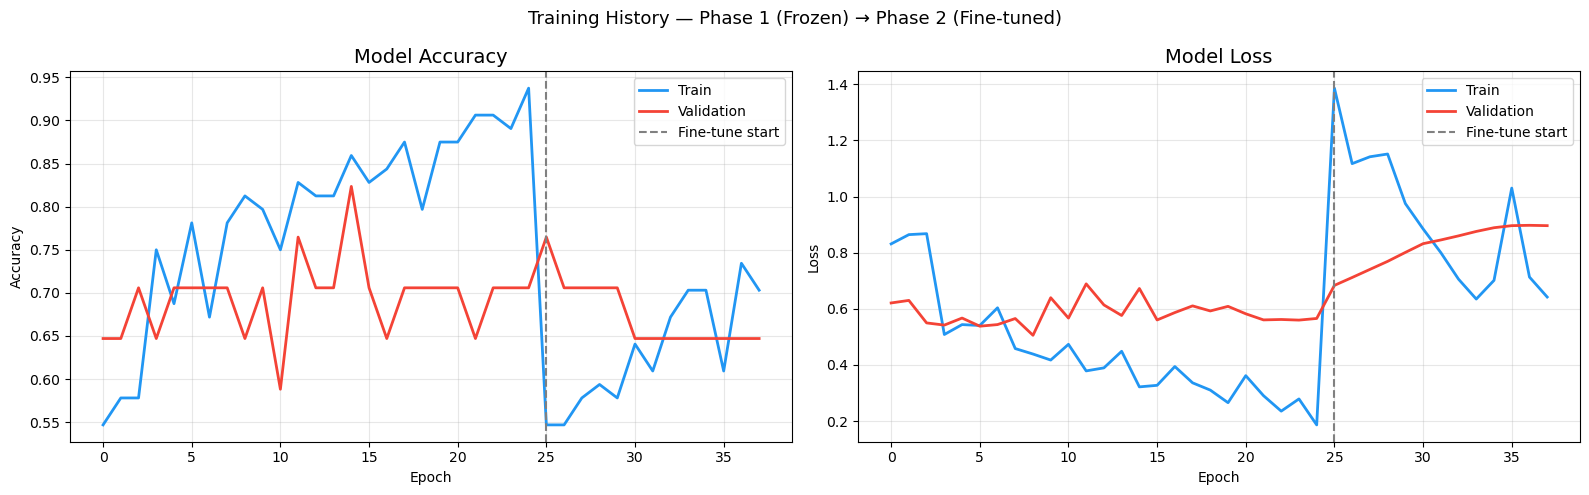

In [12]:
import matplotlib.pyplot as plt


acc     = history1.history['accuracy']     + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss    = history1.history['loss']         + history2.history['loss']
val_loss= history1.history['val_loss']     + history2.history['val_loss']
phase_boundary = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, train_v, val_v, title, ylabel in zip(
    axes,
    [acc,  loss],
    [val_acc, val_loss],
    ["Model Accuracy", "Model Loss"],
    ["Accuracy",       "Loss"]
):
    ax.plot(train_v, label='Train',      color='#2196F3', linewidth=2)
    ax.plot(val_v,   label='Validation', color='#F44336', linewidth=2)
    ax.axvline(x=phase_boundary, color='gray', linestyle='--', label='Fine-tune start')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Training History — Phase 1 (Frozen) → Phase 2 (Fine-tuned)", fontsize=13)
plt.tight_layout()
plt.show()

## STEP 13 — K-Fold Cross Validation


In [13]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import tensorflow as tf

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

fold_accuracies = []
fold_losses     = []

print(f"Running {N_SPLITS}-Fold Cross Validation...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"{'='*50}")
    print(f"FOLD {fold}/{N_SPLITS}")
    print(f"{'='*50}")

    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

 
    fold_datagen = ImageDataGenerator(
        rotation_range=8, width_shift_range=0.08, height_shift_range=0.08,
        zoom_range=0.08, fill_mode='nearest', horizontal_flip=False
    )
    fold_gen = fold_datagen.flow(X_tr, y_tr, batch_size=8, seed=fold)


    fold_model = build_model(trainable_base=False)
    fold_model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    w = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    cw = {0: w[0], 1: w[1]}

    fold_callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=0)
    ]

    fold_model.fit(
        fold_gen,
        steps_per_epoch=max(1, len(X_tr)//8),
        epochs=30,
        validation_data=(X_val, y_val),
        class_weight=cw,
        callbacks=fold_callbacks,
        verbose=0
    )


    fold_model.layers[1].trainable = True
    for layer in fold_model.layers[1].layers[:-30]:
        layer.trainable = False
    fold_model.compile(optimizer=Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])

    fold_callbacks2 = [
        EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=0)
    ]
    fold_model.fit(
        fold_gen,
        steps_per_epoch=max(1, len(X_tr)//8),
        epochs=20,
        validation_data=(X_val, y_val),
        class_weight=cw,
        callbacks=fold_callbacks2,
        verbose=0
    )

    val_loss, val_acc = fold_model.evaluate(X_val, y_val, verbose=0)
    fold_accuracies.append(val_acc)
    fold_losses.append(val_loss)
    print(f"Fold {fold} — Accuracy: {val_acc:.4f} | Loss: {val_loss:.4f}")

print(f"\n{'='*50}")
print(f"K-FOLD RESULTS ({N_SPLITS} folds)")
print(f"Mean Accuracy : {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")
print(f"Mean Loss     : {np.mean(fold_losses):.4f} ± {np.std(fold_losses):.4f}")
print(f"{'='*50}")

Running 5-Fold Cross Validation...

FOLD 1/5
Fold 1 — Accuracy: 0.7059 | Loss: 0.5701
FOLD 2/5


D:\Anaconda\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Fold 2 — Accuracy: 0.7500 | Loss: 0.5213
FOLD 3/5


D:\Anaconda\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Fold 3 — Accuracy: 0.7500 | Loss: 0.6550
FOLD 4/5


D:\Anaconda\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Fold 4 — Accuracy: 0.8125 | Loss: 0.5766
FOLD 5/5


D:\Anaconda\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Fold 5 — Accuracy: 0.8750 | Loss: 0.5714

K-FOLD RESULTS (5 folds)
Mean Accuracy : 0.7787 ± 0.0589
Mean Loss     : 0.5789 ± 0.0430


## STEP 14 — K-Fold Results Visualization

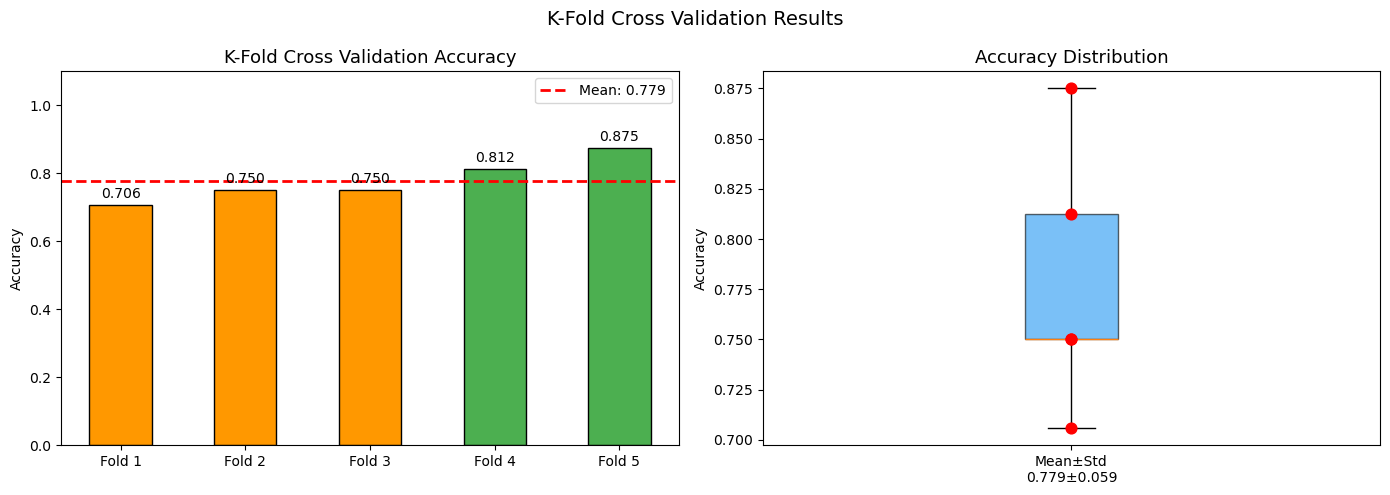

In [14]:
import matplotlib.pyplot as plt
import numpy as np

folds = [f"Fold {i}" for i in range(1, N_SPLITS+1)]
colors = ['#4CAF50' if a >= np.mean(fold_accuracies) else '#FF9800' for a in fold_accuracies]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(folds, fold_accuracies, color=colors, edgecolor='black', width=0.5)
axes[0].axhline(np.mean(fold_accuracies), color='red', linestyle='--', linewidth=2,
                label=f"Mean: {np.mean(fold_accuracies):.3f}")
axes[0].set_title("K-Fold Cross Validation Accuracy", fontsize=13)
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim([0, 1.1])
axes[0].legend()
for bar, acc in zip(bars, fold_accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{acc:.3f}", ha='center', fontsize=10)

axes[1].boxplot(fold_accuracies, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#2196F3', alpha=0.6))
axes[1].scatter([1]*len(fold_accuracies), fold_accuracies, color='red', zorder=5, s=60)
axes[1].set_title("Accuracy Distribution", fontsize=13)
axes[1].set_ylabel("Accuracy")
axes[1].set_xticks([1])
axes[1].set_xticklabels([f"Mean±Std\n{np.mean(fold_accuracies):.3f}±{np.std(fold_accuracies):.3f}"])

plt.suptitle("K-Fold Cross Validation Results", fontsize=14)
plt.tight_layout()
plt.show()

## STEP 15 — Final Evaluation on Test Set

In [15]:
import numpy as np


best_model = tf.keras.models.load_model('parkinson_cnn_model.h5')


y_prob = best_model.predict(X_test, verbose=0).flatten()


best_thresh, best_acc = 0.5, 0
for thresh in np.arange(0.3, 0.71, 0.05):
    preds = (y_prob >= thresh).astype(int)
    acc = np.mean(preds == y_test)
    if acc > best_acc:
        best_acc = acc
        best_thresh = thresh

print(f"Optimal threshold: {best_thresh:.2f}")
print(f"Test Accuracy    : {best_acc:.4f} ({best_acc*100:.1f}%)")

y_pred = (y_prob >= best_thresh).astype(int)

Optimal threshold: 0.45
Test Accuracy    : 0.7647 (76.5%)


## STEP 16 — Confusion Matrix

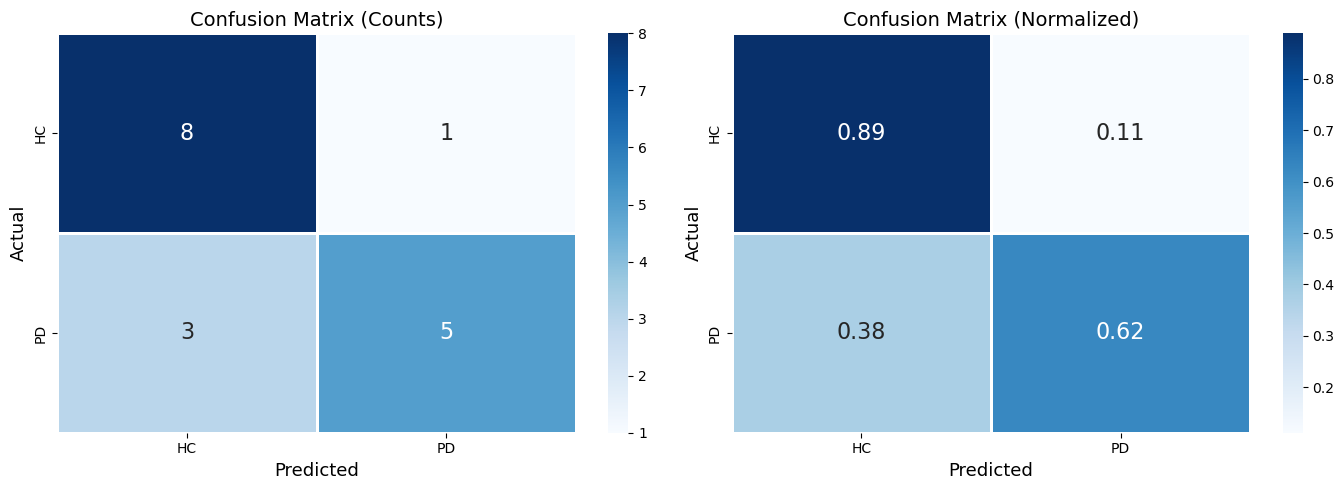


Classification Report:
              precision    recall  f1-score   support

          HC       0.73      0.89      0.80         9
          PD       0.83      0.62      0.71         8

    accuracy                           0.76        17
   macro avg       0.78      0.76      0.76        17
weighted avg       0.78      0.76      0.76        17



In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['HC','PD'], yticklabels=['HC','PD'],
            linewidths=1, linecolor='white', annot_kws={'size': 16})
axes[0].set_xlabel("Predicted", fontsize=13)
axes[0].set_ylabel("Actual",    fontsize=13)
axes[0].set_title("Confusion Matrix (Counts)", fontsize=14)


cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=['HC','PD'], yticklabels=['HC','PD'],
            linewidths=1, linecolor='white', annot_kws={'size': 16})
axes[1].set_xlabel("Predicted", fontsize=13)
axes[1].set_ylabel("Actual",    fontsize=13)
axes[1].set_title("Confusion Matrix (Normalized)", fontsize=14)

plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['HC','PD']))

## STEP 17 — ROC Curve & AUC Score

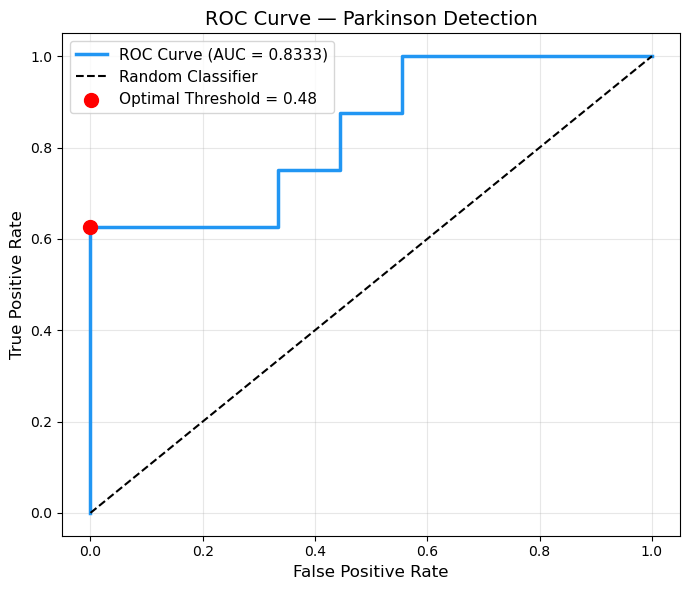

ROC-AUC Score: 0.8333
Interpretation: Good discriminator


In [17]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#2196F3', linewidth=2.5,
        label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')


opt_idx = np.argmax(tpr - fpr)
ax.scatter(fpr[opt_idx], tpr[opt_idx], s=100, color='red', zorder=5,
           label=f'Optimal Threshold = {thresholds[opt_idx]:.2f}')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — Parkinson Detection', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"Interpretation: {'Excellent' if roc_auc>=0.9 else 'Good' if roc_auc>=0.8 else 'Fair' if roc_auc>=0.7 else 'Poor'} discriminator")

## STEP 18 — Full Metrics Summary


      FINAL MODEL PERFORMANCE SUMMARY
  Accuracy              : 0.7647
  Precision (HC)        : 0.7273
  Recall (HC)           : 0.8889
  F1-Score (HC)         : 0.8000
  Precision (PD)        : 0.8333
  Recall (PD)           : 0.6250
  F1-Score (PD)         : 0.7143
  ROC-AUC               : 0.8333
  K-Fold Mean Acc       : 0.7787
  K-Fold Std            : 0.0589


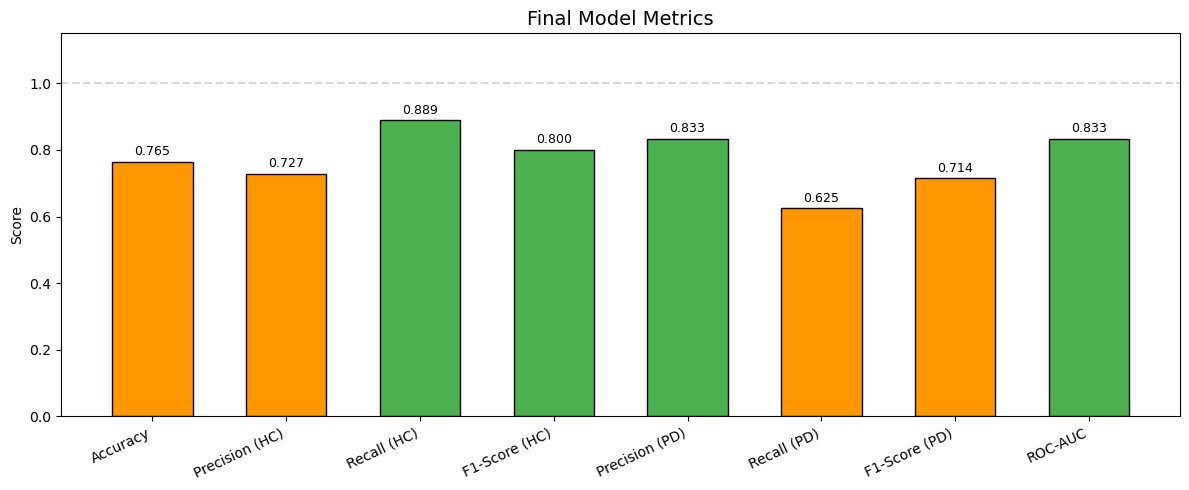

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

metrics = {
    'Accuracy':           accuracy_score(y_test, y_pred),
    'Precision (HC)':     precision_score(y_test, y_pred, pos_label=0),
    'Recall (HC)':        recall_score(y_test, y_pred, pos_label=0),
    'F1-Score (HC)':      f1_score(y_test, y_pred, pos_label=0),
    'Precision (PD)':     precision_score(y_test, y_pred, pos_label=1),
    'Recall (PD)':        recall_score(y_test, y_pred, pos_label=1),
    'F1-Score (PD)':      f1_score(y_test, y_pred, pos_label=1),
    'ROC-AUC':            roc_auc_score(y_test, y_prob),
    'K-Fold Mean Acc':    np.mean(fold_accuracies),
    'K-Fold Std':         np.std(fold_accuracies),
}

print("\n" + "="*45)
print("      FINAL MODEL PERFORMANCE SUMMARY")
print("="*45)
for k, v in metrics.items():
    print(f"  {k:<22}: {v:.4f}")
print("="*45)


import matplotlib.pyplot as plt
plot_metrics = {k: v for k, v in metrics.items() if 'Std' not in k and 'K-Fold' not in k}
colors = ['#4CAF50' if v >= 0.8 else '#FF9800' if v >= 0.6 else '#F44336'
          for v in plot_metrics.values()]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(list(plot_metrics.keys()), list(plot_metrics.values()),
               color=colors, edgecolor='black', width=0.6)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.3)
ax.set_title("Final Model Metrics", fontsize=14)
ax.set_ylabel("Score")
ax.set_ylim([0, 1.15])
plt.xticks(rotation=25, ha='right', fontsize=10)
for bar, v in zip(bars, plot_metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{v:.3f}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## STEP 19 — Predict on a New Audio File

In [19]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tempfile, os, cv2
import tensorflow as tf

def predict_parkinson(audio_path, model, img_size=224, threshold=0.5):

    y, sr = librosa.load(audio_path, sr=16000)
    y_trim, _ = librosa.effects.trim(y, top_db=20)
    if np.max(np.abs(y_trim)) != 0:
        y_norm = y_trim / np.max(np.abs(y_trim))
    else:
        y_norm = y_trim

 
    mel = librosa.feature.melspectrogram(y=y_norm, sr=sr, n_mels=128, n_fft=2048, hop_length=512)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tmp:
        tmp_path = tmp.name

    fig = plt.figure(figsize=(img_size/100, img_size/100), dpi=100)
    ax  = fig.add_axes([0, 0, 1, 1])
    librosa.display.specshow(mel_db, sr=sr, cmap='magma', ax=ax)
    ax.axis('off')
    plt.savefig(tmp_path, dpi=100, bbox_inches='tight', pad_inches=0)
    plt.close(fig)

    img = cv2.imread(tmp_path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    os.unlink(tmp_path)

    img_tensor = np.expand_dims(img.astype(np.float32) / 255.0, axis=0)

 
    prob = model.predict(img_tensor, verbose=0)[0][0]
    label = "PD (Parkinson's)" if prob >= threshold else "HC (Healthy Control)"
    confidence = prob if prob >= threshold else 1 - prob

    return label, float(confidence), float(prob)



TEST_AUDIO = "dataset/raw/HC/HC_AH/" + os.listdir("dataset/raw/HC/HC_AH")[0]

best_model = tf.keras.models.load_model('parkinson_cnn_model.h5')
label, confidence, raw_prob = predict_parkinson(TEST_AUDIO, best_model, threshold=best_thresh)

print(f"Audio file : {os.path.basename(TEST_AUDIO)}")
print(f"Prediction : {label}")
print(f"Confidence : {confidence*100:.1f}%")
print(f"PD probability: {raw_prob:.4f}")

Audio file : AH_064F_7AB034C9-72E4-438B-A9B3-AD7FDA1596C5.wav
Prediction : HC (Healthy Control)
Confidence : 94.9%
PD probability: 0.0507


## STEP 20 — Save Final Model

In [20]:


def predict_parkinson_numeric(audio_path, model, img_size=224, threshold=0.5):
    label, confidence, prob = predict_parkinson(
        audio_path, model, img_size=img_size, threshold=threshold
    )
    
    numeric_label = 1 if prob >= threshold else 0
    return numeric_label, prob



num_label, prob = predict_parkinson_numeric(TEST_AUDIO, best_model, threshold=best_thresh)

print(f"Numeric Prediction (0=HC, 1=PD): {num_label}")
print(f"PD Probability: {prob:.4f}")

Numeric Prediction (0=HC, 1=PD): 0
PD Probability: 0.0507


In [21]:

import tensorflow as tf
saved = tf.keras.models.load_model('parkinson_cnn_model.h5')
print("Model loaded successfully!")
print(f"Input shape : {saved.input_shape}")
print(f"Output shape: {saved.output_shape}")
print(f"Total params: {saved.count_params():,}")

Model loaded successfully!
Input shape : (None, 224, 224, 3)
Output shape: (None, 1)
Total params: 2,618,945


In [22]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tempfile, os, cv2

def predict_parkinson(audio_path, model, img_size=224, threshold=0.5):
    y, sr = librosa.load(audio_path, sr=16000)
    y_trim, _ = librosa.effects.trim(y, top_db=20)

    if np.max(np.abs(y_trim)) != 0:
        y_norm = y_trim / np.max(np.abs(y_trim))
    else:
        y_norm = y_trim

    mel = librosa.feature.melspectrogram(y=y_norm, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tmp:
        tmp_path = tmp.name

    plt.figure(figsize=(2.24, 2.24))
    librosa.display.specshow(mel_db, sr=sr, cmap='magma')
    plt.axis('off')
    plt.savefig(tmp_path, bbox_inches='tight', pad_inches=0)
    plt.close()

    img = cv2.imread(tmp_path)
    img = cv2.resize(img, (224, 224))
    os.unlink(tmp_path)

    img = np.expand_dims(img / 255.0, axis=0)

    prob = model.predict(img, verbose=0)[0][0]

    label = "PD (Parkinson's)" if prob >= threshold else "HC (Healthy)"
    confidence = prob if prob >= threshold else 1 - prob

    return label, confidence, prob

In [23]:
import tensorflow as tf
import os


model = tf.keras.models.load_model('parkinson_cnn_model.h5')


best_thresh = 0.5 


audio_path = "koshalbhai2.wav"


label, confidence, raw_prob = predict_parkinson(audio_path, model, threshold=best_thresh)


binary_output = 1 if label.startswith("PD") else 0

print("──────── RESULT ────────")
print(f"File Path      : {audio_path}")
print(f"Prediction     : {label}")
print(f"Binary Output  : {binary_output}  (1 = Parkinson's, 0 = Healthy)")
print(f"Confidence     : {confidence*100:.2f}%")
print(f"Raw Probability: {raw_prob:.4f}")

──────── RESULT ────────
File Path      : koshalbhai2.wav
Prediction     : HC (Healthy)
Binary Output  : 0  (1 = Parkinson's, 0 = Healthy)
Confidence     : 62.52%
Raw Probability: 0.3748
